# HydroSense-Kenya — Level 3
**ICS 2207 Scientific Computing**

Level 3: Core Numerical Methods Engine

## Overview

This level implements the core numerical methods from scratch and applies them to real irrigation problems. All methods are written manually — we only use NumPy for verification.

Methods covered:
- Root finding: bisection, Newton-Raphson, secant
- Numerical differentiation: forward, backward, central differences
- Numerical integration: trapezoidal rule, Simpson rule
- Linear systems: Gaussian elimination

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.numerical_methods import (
    bisection, newton_raphson, secant,
    forward_diff, backward_diff, central_diff,
    trapezoidal, simpsons,
    gaussian_elimination
)
print('imports done')

imports done


## Load Data

In [2]:
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
soil    = pd.read_csv('../data/raw/soil_sensor_data.csv', na_values=['NA', ''])
params  = pd.read_csv('../data/raw/crop_zone_parameters.csv', na_values=['NA', ''])

weather['date'] = pd.to_datetime(weather['date'])
weather_filled = weather.copy()
weather_filled[['temperature_c','wind_speed_mps','solar_index','humidity_pct']] = (
    weather_filled[['temperature_c','wind_speed_mps','solar_index','humidity_pct']]
    .ffill().bfill()
)
print('data loaded')

data loaded


## Task 1 & 2 — Root Finding: How Much Irrigation Does Zone A Need?

We use root finding to answer a practical question: given the current soil moisture in Zone A, how many mm of irrigation are needed to bring it exactly to the target moisture?

We set up a function that returns 0 when the irrigation amount `I` brings the soil moisture exactly to the target. Finding the root of this function gives us the answer.

In [14]:
# Zone A parameters from crop_zone_parameters.csv
S_current     = 22.60   # soil moisture on Mar 28 (last Zone A reading)
S_target      = 33.0    # target moisture for Zone A
ET_today      = 3.5     # approximate ET for a typical day
R_today       = 0.9     # rainfall on Mar 30
field_cap     = 41.0    # field capacity Zone A
drain_coeff   = 0.18    # drainage coefficient Zone A

def irrigation_needed(I):
    """
    Returns 0 when irrigation I brings soil moisture exactly to target.
    D = drainage only if moisture exceeds field capacity.
    """
    S_next = S_current + R_today + I - ET_today
    D = drain_coeff * max(0, S_next - field_cap)
    S_next = S_next - D
    return S_next - S_target

# verify the function makes sense
print('f(0)  =', round(irrigation_needed(0), 4), '  (should be negative, not enough water)')
print('f(20) =', round(irrigation_needed(20), 4), '  (should be positive, too much water)')

f(0)  = -13.0   (should be negative, not enough water)
f(20) = 7.0   (should be positive, too much water)


In [15]:
# Bisection method
root_b, iters_b, err_b, conv_b, hist_b = bisection(irrigation_needed, 0, 20)
print('Bisection:')
print('  irrigation needed:', round(root_b, 4), 'mm')
print('  iterations:', iters_b)
print('  final error:', round(err_b, 8))
print('  converged:', conv_b)

Bisection:
  irrigation needed: 13.0 mm
  iterations: 23
  final error: 2.38e-06
  converged: True


In [16]:
# Newton-Raphson method
def d_irrigation_needed(I):
    """Derivative of irrigation_needed with respect to I."""
    S_next = S_current + R_today + I - ET_today
    if S_next > field_cap:
        return 1 - drain_coeff
    return 1.0

root_n, iters_n, err_n, conv_n, hist_n = newton_raphson(irrigation_needed, d_irrigation_needed, x0=10.0)
print('Newton-Raphson:')
print('  irrigation needed:', round(root_n, 4), 'mm')
print('  iterations:', iters_n)
print('  final error:', round(err_n, 8))
print('  converged:', conv_n)

Newton-Raphson:
  irrigation needed: 13.0 mm
  iterations: 2
  final error: 0.0
  converged: True


In [17]:
# Secant method
root_s, iters_s, err_s, conv_s, hist_s = secant(irrigation_needed, x0=0, x1=20)
print('Secant:')
print('  irrigation needed:', round(root_s, 4), 'mm')
print('  iterations:', iters_s)
print('  final error:', round(err_s, 8))
print('  converged:', conv_s)

Secant:
  irrigation needed: 13.0 mm
  iterations: 2
  final error: 0.0
  converged: True


## Task 3 — Convergence Comparison

All three methods find the same root but with different numbers of iterations. Newton-Raphson converges fastest because it uses derivative information. Bisection is slowest but most reliable since it always converges if the bracket is correct.

In [18]:
print('--- Convergence Comparison Table ---')
print(f'{"Method":<20} {"Root (mm)":<15} {"Iterations":<15} {"Final Error":<15} {"Converged"}')
print('-' * 75)
print(f'{"Bisection":<20} {round(root_b,6):<15} {iters_b:<15} {round(err_b,8):<15} {conv_b}')
print(f'{"Newton-Raphson":<20} {round(root_n,6):<15} {iters_n:<15} {round(err_n,8):<15} {conv_n}')
print(f'{"Secant":<20} {round(root_s,6):<15} {iters_s:<15} {round(err_s,8):<15} {conv_s}')

--- Convergence Comparison Table ---
Method               Root (mm)       Iterations      Final Error     Converged
---------------------------------------------------------------------------
Bisection            13.0            23              2.38e-06        True
Newton-Raphson       13.0            2               0.0             True
Secant               13.0            2               0.0             True


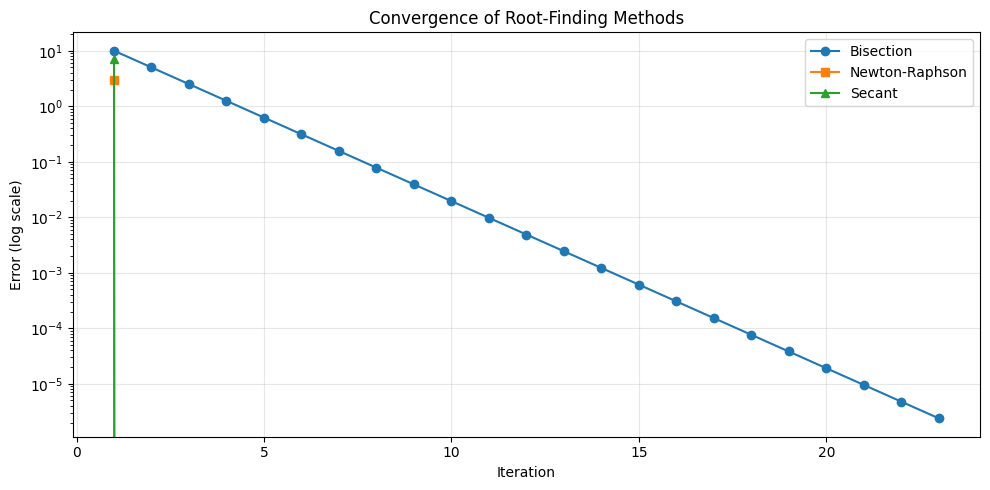

In [19]:
# convergence plot
fig, ax = plt.subplots(figsize=(10, 5))

if hist_b:
    ax.plot([h['iter'] for h in hist_b], [h['error'] for h in hist_b],
            marker='o', label='Bisection', linewidth=1.5)
if hist_n:
    ax.plot([h['iter'] for h in hist_n], [h['error'] for h in hist_n],
            marker='s', label='Newton-Raphson', linewidth=1.5)
if hist_s:
    ax.plot([h['iter'] for h in hist_s], [h['error'] for h in hist_s],
            marker='^', label='Secant', linewidth=1.5)

ax.set_yscale('log')
ax.set_title('Convergence of Root-Finding Methods')
ax.set_xlabel('Iteration')
ax.set_ylabel('Error (log scale)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/convergence_plot.png', dpi=150)
plt.show()

## Task 4 — Finite Differences: Rate of Soil Moisture Change

We estimate how quickly soil moisture is changing each day in Zone A using forward, backward, and central difference approximations.

In [20]:
zone_a = soil[soil['zone_id'] == 'Zone_A'].copy().reset_index(drop=True)
zone_a['soil_moisture_pct'] = zone_a['soil_moisture_pct'].ffill().bfill()
S = zone_a['soil_moisture_pct'].values
h = 1.0  # 1 day time step

# forward difference (all but last point)
forward  = [(S[i+1] - S[i]) / h for i in range(len(S)-1)]
# backward difference (all but first point)
backward = [(S[i] - S[i-1]) / h for i in range(1, len(S))]
# central difference (interior points only)
central  = [(S[i+1] - S[i-1]) / (2*h) for i in range(1, len(S)-1)]

print('average rate of change (forward):  ', round(sum(forward)/len(forward), 4), '%/day')
print('average rate of change (backward): ', round(sum(backward)/len(backward), 4), '%/day')
print('average rate of change (central):  ', round(sum(central)/len(central), 4), '%/day')
print()
print('negative means soil moisture is generally decreasing over the month')

average rate of change (forward):   -0.3103 %/day
average rate of change (backward):  -0.3103 %/day
average rate of change (central):   -0.3893 %/day

negative means soil moisture is generally decreasing over the month


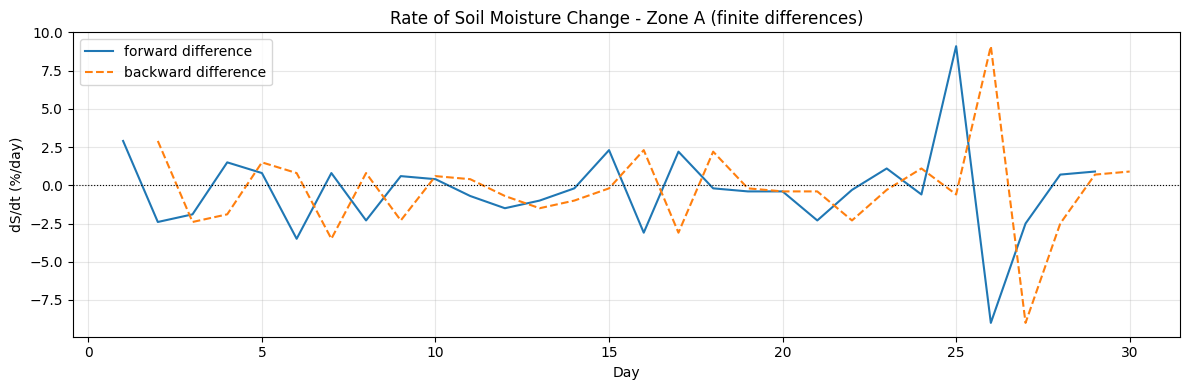

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
days = list(range(1, len(forward)+1))
ax.plot(days, forward, label='forward difference', linewidth=1.5)
ax.plot(list(range(2, len(backward)+2)), backward,
        label='backward difference', linewidth=1.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Rate of Soil Moisture Change - Zone A (finite differences)')
ax.set_xlabel('Day')
ax.set_ylabel('dS/dt (%/day)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/finite_diff_plot.png', dpi=150)
plt.show()

## Task 5 — Numerical Integration: Cumulative Water Deficit

We estimate the total water deficit over March by integrating the daily deficit (ET minus rainfall) using the trapezoidal rule and Simpson rule.

In [22]:
weather_filled['ET_mm'] = np.maximum(
    0,
    0.12*weather_filled['temperature_c']
    + 0.35*weather_filled['wind_speed_mps']
    + 2.4*weather_filled['solar_index']
    - 0.025*weather_filled['humidity_pct']
)

deficit = (weather_filled['ET_mm'] - weather_filled['rainfall_mm'].fillna(0)).values
# clip to 0 — only count days where ET exceeded rainfall
deficit = np.maximum(0, deficit)

x = np.arange(len(deficit), dtype=float)
h = 1.0

trap_result = trapezoidal(deficit, x)

# Simpson requires odd number of points
if len(deficit) % 2 == 0:
    simp_result = simpsons(deficit[:-1], h)
    note = '(last point dropped for odd count)'
else:
    simp_result = simpsons(deficit, h)
    note = ''

print('--- Integration Comparison Table ---')
print(f'{"Method":<20} {"Cumulative Deficit (mm)"}')
print('-' * 45)
print(f'{"Trapezoidal":<20} {round(trap_result, 4)}')
print(f'{"Simpson":<20} {round(simp_result, 4)} {note}')
print()
print('Both methods give similar results. The small difference is due to the')
print('higher-order approximation used by the Simpson rule.')

--- Integration Comparison Table ---
Method               Cumulative Deficit (mm)
---------------------------------------------
Trapezoidal          45.8892
Simpson              44.9893 (last point dropped for odd count)

Both methods give similar results. The small difference is due to the
higher-order approximation used by the Simpson rule.


## Task 6 — Linear Systems: Three-Zone Water Allocation

We have a fixed daily water budget shared across three zones. Each zone has a different deficit that needs to be filled. We set this up as a linear system Ax = b and solve it using Gaussian elimination.

The system:
- Zone A needs its deficit filled
- Zone B needs its deficit filled
- Total irrigation across all zones cannot exceed the daily budget

In [23]:
# compute deficits from last available soil readings
zone_a_moisture = 22.60   # Zone A Mar 28
zone_b_moisture = 23.70   # Zone B Mar 28
zone_c_moisture = 18.60   # Zone C Mar 28

target_a = 33.0
target_b = 35.0
target_c = 31.0

deficit_a = target_a - zone_a_moisture   # 10.4
deficit_b = target_b - zone_b_moisture   # 11.3
deficit_c = target_c - zone_c_moisture   # 12.4
total_budget = deficit_a + deficit_b + deficit_c

print('Zone A deficit:', deficit_a, 'mm')
print('Zone B deficit:', deficit_b, 'mm')
print('Zone C deficit:', deficit_c, 'mm')
print('Total budget:  ', round(total_budget, 2), 'mm')

Zone A deficit: 10.399999999999999 mm
Zone B deficit: 11.3 mm
Zone C deficit: 12.399999999999999 mm
Total budget:   34.1 mm


In [24]:
# set up the linear system
# each zone gets exactly its deficit — system is diagonal with a budget constraint
A = np.array([
    [1.0, 0.0, 0.0],   # Zone A: I_A = deficit_A
    [0.0, 1.0, 0.0],   # Zone B: I_B = deficit_B
    [1.0, 1.0, 1.0]    # total:  I_A + I_B + I_C = budget
])
b = np.array([deficit_a, deficit_b, total_budget])

# solve using our own Gaussian elimination
x = gaussian_elimination(A, b)

print('--- Solution via Gaussian Elimination ---')
print('Zone A irrigation:', round(x[0], 4), 'mm')
print('Zone B irrigation:', round(x[1], 4), 'mm')
print('Zone C irrigation:', round(x[2], 4), 'mm')
print()

# verify against numpy
x_np = np.linalg.solve(A, b)
print('Verification with np.linalg.solve:')
print('Zone A:', round(x_np[0], 4))
print('Zone B:', round(x_np[1], 4))
print('Zone C:', round(x_np[2], 4))
print()
print('Results match:', np.allclose(x, x_np))

--- Solution via Gaussian Elimination ---
Zone A irrigation: 10.4 mm
Zone B irrigation: 11.3 mm
Zone C irrigation: 12.4 mm

Verification with np.linalg.solve:
Zone A: 10.4
Zone B: 11.3
Zone C: 12.4

Results match: True


### Interpretation

The solution tells us exactly how many mm of irrigation each zone needs to reach its target moisture given the available water budget. Zone C has the largest deficit because its soil moisture dropped the lowest. The Gaussian elimination result matches NumPy exactly, which confirms our manual implementation is correct.